# CC-WBT-AI — Input Pipeline

Workflow: set inputs → write to files → run engine → read outputs

In [6]:
import sys, os
import openpyxl as _xl
from dotenv import load_dotenv
load_dotenv()
 
_cwd = os.path.abspath('')
if os.path.exists(os.path.join(_cwd, 'backend')):
    ROOT = _cwd
elif os.path.exists(os.path.join(_cwd, '..', 'backend')):
    ROOT = os.path.dirname(_cwd)
else:
    raise FileNotFoundError("Cannot find the backend folder")
 
BACKEND   = os.path.join(ROOT, 'backend')
NOTEBOOKS = os.path.join(ROOT, 'notebooks')
sys.path.insert(0, BACKEND)
sys.path.insert(0, NOTEBOOKS)

from pipeline_helpers import PipelineIO
from optimizer import run_optimization
print('Setup OK')

Setup OK


## 1. Model and technologies

In [7]:
COUNTRY    = 'Mozambique'
MODEL      = 'CleanStep'
TECHS      = ['Electricity', 'LPG']
START_YEAR = 2023
END_YEAR   = 2034
YEARS      = list(range(START_YEAR, END_YEAR + 1))
 
pio = PipelineIO(backend=BACKEND, country=COUNTRY, model=MODEL, techs=TECHS, start_year=START_YEAR, end_year=END_YEAR)
pio.ensure_model_exists()

  Copied fuel-financial-inputs.xlsx from template
  Copied carbon-credits.xlsx from template
Files to recreate from templates:
  design-capital-CleanStep.xlsx: does not exist
  technoeconomic-inputs-CleanStep.xlsx: does not exist
  financial-statements-CleanStep.xlsx: does not exist
  capex-fuels-CleanStep.xlsx: does not exist
  design-capital-CleanStep.xlsx
  technoeconomic-inputs-CleanStep.xlsx
  financial-statements-CleanStep.xlsx
  capex-fuels-CleanStep.xlsx
Model CleanStep ready.


## 2. Country-level inputs

In [8]:
# config
TAX_RATE  = 28
INFLATION = 5
 
# fuel financial inputs
FUEL_FIN = {
    'Electricity': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
    'LPG': {
        'NTL':      [5]*12,
        'DAYS_REC': [30]*12,
        'DAYS_PAY': [30]*12,
    },
}
 
# carbon credits (fuel-financial-inputs)
CC_CO2_CERT  = [0]*12
CC_LIQUIDITY = [0]*12
CC_PRICE_TON = [0]*12
CC_NUM_YEARS = 0
 
print('Country-level inputs defined.')

Country-level inputs defined.


## 3. Model-level inputs

In [9]:
# technoeconomic-inputs - Electricity (GRID/OFF-GRID)
TECHNO_ELEC = {
    'Electricity & E-Cooking': {
        'GRID': {
            'Demand':             [1473.6, 1616.8, 1793.2, 1954.5, 2101.6, 2235.1, 2355.9, 2518.5, 2659.5, 2786.4, 2900, 3001],
            'CAPEX - Growth':     [257.3,  324.6,  321.4,  318.2, 315, 311.8, 382, 451.1, 446.6, 442.1, 437.7, 290.8],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [48.2,   54.6,   62.2,   69.6, 77, 84.1, 91.1, 102.2, 112.7, 123, 133.1, 143],
            'D&A':                35,
        },
        'OFF-GRID': {
            'Demand':             [368.4, 379.3, 393.6, 400.3, 400.3, 394.4, 383.5, 376.3, 362.7, 344.4, 322.2, 296.8],
            'CAPEX - Growth':     [39.5,  50.3, 49.8, 49.3, 48.8, 48.4, 15.4, -17.1, -16.9, -16.8, -16.6, -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,  64.7, 74.9, 84.8, 94.5, 104, 113.4, 111.6, 105.1, 98.8, 92.6, 86.4],
            'D&A':                25,
        },
    },
    'Electricity (Low access)': {
        'GRID': {
            'Demand':              [1442.6, 1496.4, 1584.4, 1666.1, 1741.6, 1811.1, 1874.7, 1933.7, 1991.3, 2044.1, 2092.2, 2135.7],
            'CAPEX - Growth':      [214.8,   248.1,   245.6,   243.1,   240.7,   238.3,   276.1,   313.4,   310.3,   307.2,   304.1,   208.6],
            'CAPEX - Maintenance': [0]*12,
            'OPEX':                [46.2,    47.9,    50.9,    53.8,    56.7,    59.5,    62.2,    71,    81.3,    91.4,    101.3,   111  ],
            'D&A': 35,
        },
        'OFF-GRID': {
            'Demand':             [368.4,  379.3,  393.6,  400.3,  400.3,  394.4,  383.5,  376.3,  362.7,  344.4,  322.2,  296.8],
            'CAPEX - Growth':     [39.5,   50.3,   49.8,   49.3,   48.8,   48.4,   15.4,   -17.1,  -16.9,  -16.8,  -16.6,  -1.7],
            'CAPEX - Maintenance':[0]*12,
            'OPEX':               [56.1,   64.7,   74.9,   84.8,   94.5,   104.0,  113.4,  111.6,  105.1,  98.8,   92.6,   86.5],
            'D&A': 25,
        },
    },
}
 
# technoeconomic-inputs — LPG (other fuels)
TECHNO_LPG = {
    'Demand':             [301.9,  326.6,  438.7,  539.3,  629.3,  709.6,  780.8,  970.5,  949.4,  928.2,  906.8,  885.4],
    'CAPEX - Growth':     [2.7,    4.8,    4.8,    4.7,    4.7,    4.7,    3.7,    2.6,    2.6,    2.6,    2.6,    2.5],
    'CAPEX - Maintenance':[0]*12,
    'OPEX':               [25.5,   36.4,   51.4,   66.3,   81.2,   96.0,   110.8,  115.4,  118.1,  120.7,  123.4,  126.0],
    'D&A': 15,
}
 
# tariffs & upstreams
TARIFFS = {
    'Electricity': [0.15, 0.16, 0.17, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.26],
    'LPG':         [0.08, 0.08, 0.08, 0.09, 0.09, 0.10, 0.10, 0.11, 0.11, 0.12, 0.12, 0.13],
}
UPSTREAMS = {
    'Electricity': [0]*12,
    'LPG':         [0]*12,
}
 
# CO2 emitted (carbon-credits)
CO2_BASELINE = [21.61, 20.602, 19.838, 19.074, 18.311, 17.547, 16.783, 16.436, 16.367, 16.298, 16.229, 16.160]
CO2_EMITTED = [21.611, 19.405, 17.428, 15.452, 13.475, 11.498, 9.521, 9.105, 9.190, 9.275, 9.360, 9.446]
 
print('Model-level inputs defined.')

Model-level inputs defined.


### Capital Structure Optimisation
Optuna searches for the combination of equity/grants/debt/costs that minimises total debt (or long-term subsidies) across the planning horizon. `SEARCH_RANGES` defines the search space and `OBJECTIVE` controls what is minimised.

In [10]:
SEARCH_RANGES = {
    'pct_equity':          (0.10, 0.50),
    'pct_grants':          (0.10, 0.60), #60
    'cost_equity':         (0.08, 0.20),
    'cost_debt':           (0.04, 0.12),
    'years_realisation':   (4, 10),
    'grace_period':        (1, 6),
    'amortization_period': (5, 30),
}
OBJECTIVE = 'debt'   # 'debt'/'lts
N_TRIALS  = 100

CAPITAL_STRUCTURE = {}
for tech, tech_dict in TECHNO_ELEC.items():
    print(f"Optimising {tech}...")
    CAPITAL_STRUCTURE[tech] = run_optimization(
        tech_dict=tech_dict,
        tax_rate=TAX_RATE,
        years=YEARS,
        fuel_fin=FUEL_FIN,
        tariffs=TARIFFS,
        fuel_key='Electricity',
        search_ranges=SEARCH_RANGES,
        objective=OBJECTIVE,
        n_trials=N_TRIALS,
    )
    print(f"  → {CAPITAL_STRUCTURE[tech]}")

print("Optimising LPG...")
CAPITAL_STRUCTURE['LPG'] = run_optimization(
    tech_dict={'GRID': TECHNO_LPG},
    tax_rate=TAX_RATE,
    years=YEARS,
    fuel_fin=FUEL_FIN,
    tariffs=TARIFFS,
    fuel_key='LPG',
    search_ranges=SEARCH_RANGES,
    objective=OBJECTIVE,
    n_trials=N_TRIALS,
)
print(f"  → {CAPITAL_STRUCTURE['LPG']}")

for sheet, cs in CAPITAL_STRUCTURE.items():
    print(f"\n{sheet}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  CAPEX  " + "".join(f"{round(v,1):>10}" for v in cs.get('CAPEX_SCHEDULE', [])))
    print("  DEBT   " + "".join(f"{round(v,1):>10}" for v in cs.get('DEBT_INCREASE',  [])))
    print("  LTS    " + "".join(f"{round(v,1):>10}" for v in cs.get('LT_SUBSIDY_SCHEDULE', [])))

Optimising Electricity & E-Cooking...
K1=0.34, K2=0.069
Trial 0: total debt=0, debt=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[215.57623825215697, 266.4804077551827, 320.006134995234, 342.8779943029029, 477.7711977108999, 223.86919036328453, 0, 712.0762932443715, 906.5886577804607, 0, 498.1704865448902, 567.583399050619], lt_subsidies=[0, 0, 0, 0, 28.556907281416045, 26.801993324829475, 0, 47.484426849947475, 105.37605669857658, 63.80397095276652, 74.22337595231555, 64.00130192364932]
Trial 1: total debt=4e+02, debt=[0, 0, 366.7689024874078, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[423.88469183382625, 180.57832224622726, 743.3469996965853, 281.44461355082046, 236.4347629936978, 267.46386638301465, 302.44489180002427, 320.8066502796749, 363.4553445739443, 411.57323969862995, 465.8562076645415, 533.7104092790169], lt_subsidies=[0, 0, 23.084686863877554, 45.246286683908494, 48.72460366413891, 51.59339314037309, 55.60222073046658, 58.93363732113081, 63.57752242575814, 69.50240870430002, 76.732

In [11]:
print(CAPITAL_STRUCTURE['LPG'])

{'K1': 17.77617880145528, 'K2': 0.12970261941767625, 'PCT_EQUITY': 47, 'PCT_DEBT': 53, 'COST_OF_EQUITY': 18, 'PCT_GRANTS': 57, 'YEARS_REALISATION': 10, 'COST_OF_DEBT': 11, 'GRACE_PERIOD': 1, 'AMORTIZATION': 8, 'DEBT_INCREASE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'CAPEX_SCHEDULE': [-9.245370111371986e-15, 0, 0, 1.099517634639498, 0.5365256605942582, 2.184692037467097, 1.9701330752541344, 4.446572336685451, 5.670321089186958, 12.80512901480702, 5.688328509337496, 8.598780642028094], 'TOTAL_LT_SUBSIDIES': 166.5578534542189, 'LT_SUBSIDY_SCHEDULE': [13.011408467069977, 13.011408467069982, 13.011408467069975, 11.911086344785888, 12.257051193576704, 11.576115838261648, 12.91292006218088, 12.643101178825479, 15.834565511252213, 17.075565805318902, 19.175996842919037, 14.137225275888262], 'PYOMO_RUNS': [{'TRIAL': 0, 'PCT_EQUITY': 0.1625384779776037, 'PCT_DEBT': 0.8374615220223963, 'PCT_GRANTS': 0.32186610640960756, 'COST_OF_EQUITY': 0.1271694898824658, 'COST_OF_DEBT': 0.09119198908529932, 'YE

## 4. Write inputs

In [12]:
print('=== COUNTRY-LEVEL ===')
pio.write_config_scalar('TAX_RATES',  TAX_RATE)
pio.write_config_scalar('INFLATIONS', INFLATION)
 
for fuel, vals in FUEL_FIN.items():
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Expected non-technical losses',        vals['NTL'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade receivables - Days of revenues', vals['DAYS_REC'])
    pio.write_timeseries_list(pio.fuel_fin_path, fuel, 'Trade payables - Days of OPEX costs',  vals['DAYS_PAY'])
 
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'CO2 certificate (%) - from the total CO2 avoided', CC_CO2_CERT)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Liquidity',     CC_LIQUIDITY)
pio.write_timeseries_list      (pio.carbon_credits_path, 'Carbon Credits', 'Price per TON', CC_PRICE_TON)
pio.write_timeseries_first_year(pio.carbon_credits_path, 'Carbon Credits', 'Number of years that you could sell those carbon credits', CC_NUM_YEARS)
 
print('=== MODEL-LEVEL ===')
for sheet, cs in CAPITAL_STRUCTURE.items():
    pio.reset_circular_rows(sheet)
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])
 
for sheet, systems in TECHNO_ELEC.items():
    for system, params in systems.items():
        for param, values in params.items():
            if param == 'D&A': pio.write_techno_da(sheet, system, values)
            else:               pio.write_techno_list(sheet, system, param, values)
 
for param, values in TECHNO_LPG.items():
    if param == 'D&A': pio.write_techno_nosystem_da('LPG', values)
    else:               pio.write_techno_nosystem_list('LPG', param, values)
 
for tech, vals in TARIFFS.items():
    pio.write_config_timeseries('TARIFFS',   tech, YEARS, vals)
for tech, vals in UPSTREAMS.items():
    pio.write_config_timeseries('UPSTREAMS', tech, YEARS, vals)
 
pio.write_carbon_row('CO2 emited - Baseline scenario', CO2_BASELINE)
pio.write_carbon_co2_emitted(CO2_EMITTED, YEARS)
print('\nAll inputs written.')

=== COUNTRY-LEVEL ===
  config.json -> TAX_RATES = 28
  config.json -> INFLATIONS = 5
  fuel-financial-inputs.xlsx / Electricity -> Expected non-technical losses
  fuel-financial-inputs.xlsx / Electricity -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / Electricity -> Trade payables - Days of OPEX costs
  fuel-financial-inputs.xlsx / LPG -> Expected non-technical losses
  fuel-financial-inputs.xlsx / LPG -> Trade receivables - Days of revenues
  fuel-financial-inputs.xlsx / LPG -> Trade payables - Days of OPEX costs
  carbon-credits.xlsx / Carbon Credits -> CO2 certificate (%) - from the total CO2 avoided
  carbon-credits.xlsx / Carbon Credits -> Liquidity
  carbon-credits.xlsx / Carbon Credits -> Price per TON
  carbon-credits.xlsx / Carbon Credits -> Number of years that you could sell those carbon credits (first year)
=== MODEL-LEVEL ===
  Reset accumulator rows for Electricity & E-Cooking in financial-statements-CleanStep.xlsx
  design-capital-CleanStep.xlsx /

## 5. Run engine

In [13]:
print('Running engine...')
df_conv = pio.run_engine_until_convergence()
print('Done.')

Running engine...
  Converged in 20 iterations.
Done.


In [14]:
df_conv

,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::LPG::Annual Cost of Service,FS::LPG::Check,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Check,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,0.000000,0.000000,0.000000,-1.985747e-13,8.0,0.000000,0.000000,0.000000,-2.124376e-14,...,1135.081657,-1.318987e+01,0.895726,-42.104274,0.000000,3865.244557,5.354301e+02,-35.749315,-3418.449315,NaN
1,2,3432.246630,1269.931253,1544.510984,-1.985747e-13,19.0,1737.703699,799.343701,973.114071,-2.124376e-14,...,1143.257257,-2.215132e+02,20.473333,-22.526667,0.000000,4258.716809,-1.068128e+04,2379.639477,-1003.060523,17333.586530
2,3,1553.719602,574.876253,699.173821,-1.985747e-13,19.0,846.998631,389.619370,474.319233,-2.124376e-14,...,1147.396057,-1.360829e+02,28.648933,-14.351067,0.000000,4572.629740,-5.121590e+03,2379.639477,-1003.060523,9267.497445
3,4,1545.498968,571.834618,695.474535,-1.985747e-13,19.0,846.998631,389.619370,474.319233,-2.124376e-14,...,1151.521657,-8.280262e+01,32.787733,-10.212267,38.818214,4859.891112,-4.496492e+03,2379.639477,-1003.060523,751.046420
4,5,1360.747686,503.476644,612.336459,-1.985747e-13,19.0,846.998631,389.619370,474.319233,-2.124376e-14,...,1155.602857,-5.747217e+01,36.913333,-6.086667,138.480306,5119.057254,-3.928893e+03,2418.457691,-964.242309,1296.077437
5,6,1040.489763,384.981212,468.220394,-1.985747e-13,19.0,808.180417,371.762992,452.581034,-2.124376e-14,...,1159.608457,-3.436800e+01,40.994533,-2.005467,265.396278,5348.686506,-3.245522e+03,2518.119783,-864.580217,1669.337008
6,7,746.077318,276.048608,335.734793,-1.985747e-13,19.0,739.518948,340.178716,414.130611,-2.124376e-14,...,1163.309257,-2.118675e+01,45.000133,2.000133,417.227668,5548.327729,-2.474731e+03,2645.035755,-737.664245,1702.230855
7,8,659.948615,244.180988,296.976877,-1.985747e-13,19.0,707.463177,325.433061,396.179379,-2.124376e-14,...,1166.480857,-1.239053e+01,48.700933,5.700933,555.522643,5717.499329,-1.959887e+03,2796.867145,-585.832855,1029.048526
8,9,659.948615,244.180988,296.976877,-1.985747e-13,19.0,707.463177,325.433061,396.179379,-2.124376e-14,...,1169.066857,-4.960508e+00,51.872533,8.872533,692.723826,5854.700512,-1.534760e+03,2935.162120,-447.537880,479.701063
9,10,659.948615,244.180988,296.976877,-1.985747e-13,19.0,707.463177,325.433061,396.179379,-2.124376e-14,...,1171.010857,3.776047e+00,54.458533,11.458533,796.429803,5958.406489,-9.756172e+02,3072.363303,-310.336697,567.503256


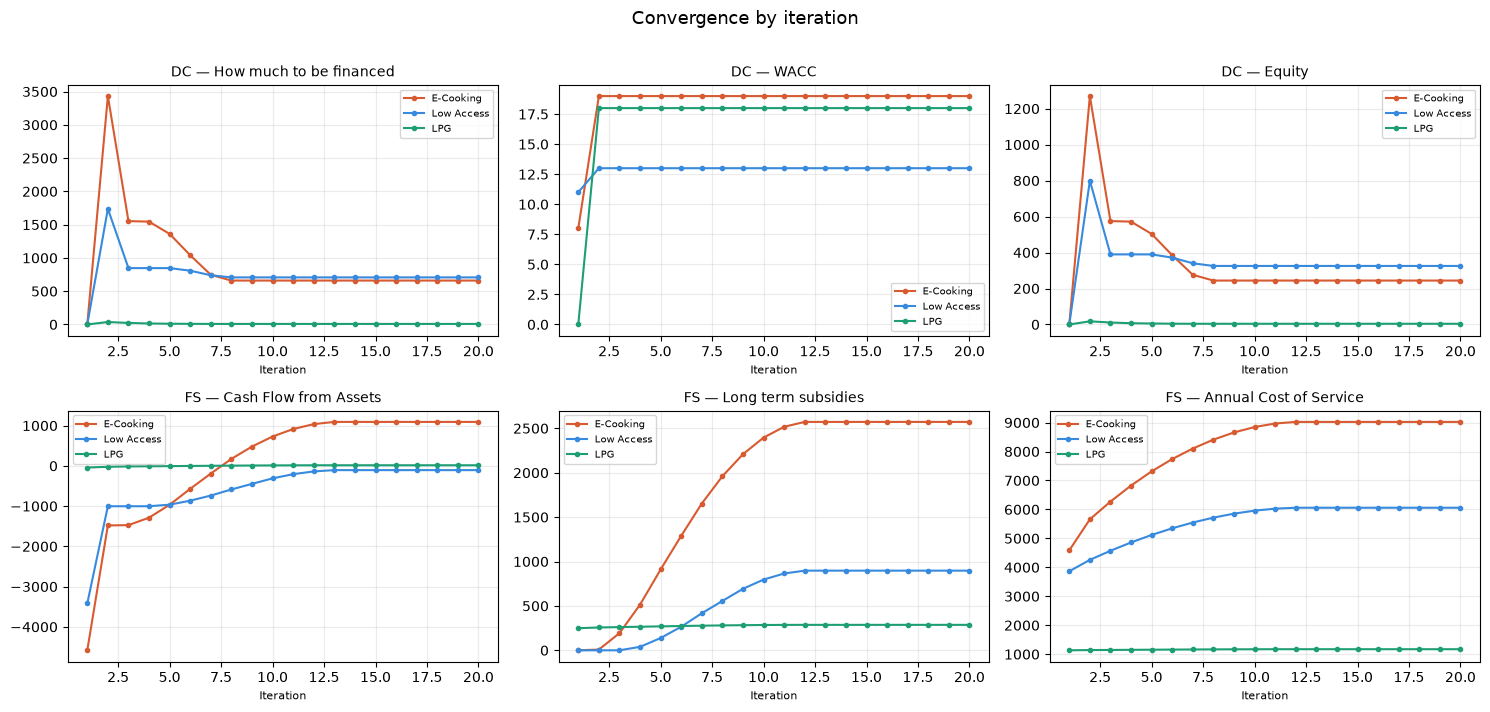

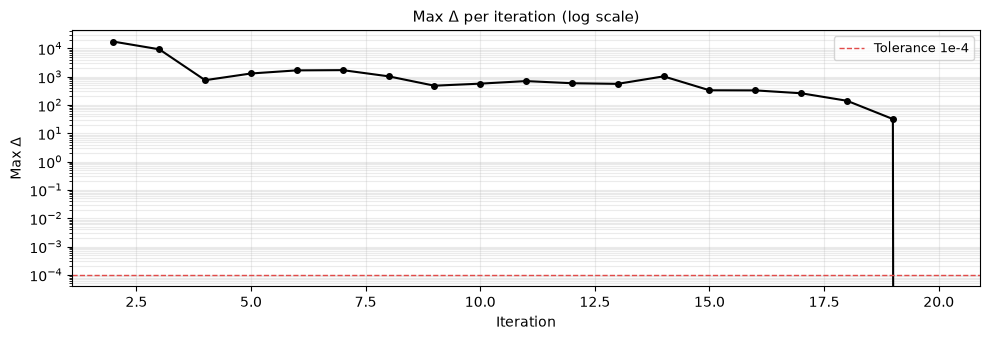

In [15]:
pio.plot_convergence(df_conv)

### Debt requirements

The platform calculates the annual debt needed to cover negative cash positions. 
Review below and optionally inject it back into the model before re-running.

In [16]:
print("=== REQUIRED DEBT PER TECHNOLOGY ===")
REQUIRED_DEBT = {}
for SHEET in pio.get_expanded_sheets():
    req = pio.read_required_debt(SHEET)
    REQUIRED_DEBT[SHEET] = req
    print(f"\n{SHEET}")
    print("  " + "".join(f"{y:>10}" for y in YEARS))
    print("  " + "".join(f"{round(v,1):>10}" for v in req))

=== REQUIRED DEBT PER TECHNOLOGY ===

Electricity & E-Cooking
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

Electricity (Low access)
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0

LPG
        2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
         0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0       0.0


In [17]:
USE_REQUIRED_DEBT = False   # True = automatically inject platform-calculated debt
DEBT_OVERRIDE     = None   # Or: {'Electricity & E-Cooking': [0, 34, 96, 0, ...]}
MAX_DEBT_ITER     = 8 
DEBT_TOL          = 0.5

accumulated = {
    sheet: list(CAPITAL_STRUCTURE[sheet].get('DEBT_INCREASE', [0]*len(YEARS)))
    for sheet in pio.get_expanded_sheets()
}

if DEBT_OVERRIDE:
    for sheet, vals in DEBT_OVERRIDE.items():
        accumulated[sheet] = list(vals)

if USE_REQUIRED_DEBT or DEBT_OVERRIDE:
    print("=== DEBT CONVERGENCE LOOP ===")
    df_conv2 = None
    for debt_iter in range(MAX_DEBT_ITER):
        total_needed = 0
        for sheet in pio.get_expanded_sheets():
            req = pio.read_required_debt(sheet)
            total_needed += sum(req)
            for t, v in enumerate(req):
                if t < len(accumulated[sheet]):
                    accumulated[sheet][t] += v

        print(f"  Iter {debt_iter+1}: remaining debt needed = {total_needed:.2f} M$")

        if total_needed < DEBT_TOL:
            print(f"  Converged in {debt_iter+1} iteration(s).")
            break

        for sheet, vals in accumulated.items():
            pio.write_design_debt_list(sheet, vals)
            CAPITAL_STRUCTURE[sheet]['DEBT_INCREASE'] = vals

        df_conv2 = pio.run_engine_until_convergence()
    else:
        print(f"  Warning: did not converge after {MAX_DEBT_ITER} iterations.")

    if df_conv2 is not None:
        display(df_conv2)

    print("\n=== FINAL INJECTED DEBT PER TECHNOLOGY ===")
    for sheet, vals in accumulated.items():
        print(f"\n{sheet}")
        print("  " + "".join(f"{y:>10}" for y in YEARS))
        print("  " + "".join(f"{round(v,1):>10}" for v in vals))
else:
    print("No debt injection applied.")

No debt injection applied.


## 6. Outputs

In [18]:
col_w = 10
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue
    print(f"\n{'='*70}")
    print(f"  {SHEET}")
    print('='*70)
    header = f"{'Row':<35}" + ''.join(f"{y:>{col_w}}" for y in YEARS)
    print(header)
    print('-' * len(header))
    for key, values in out.items():
        print(f"{key:<35}" + ''.join(f"{round(v,1):>{col_w}}" for v in values))
    check_vals = out.get('Check', [0]*len(YEARS))
    if any(abs(v) > 1 for v in check_vals):
        print(f"\n  ⚠  Balance sheet check FAILED: {[round(v,1) for v in check_vals]}")
    else:
        print(f"\n  ✓  Balance sheet OK")


  Electricity & E-Cooking
Row                                      2023      2024      2025      2026      2027      2028      2029      2030      2031      2032      2033      2034
-----------------------------------------------------------------------------------------------------------------------------------------------------------
Long term subsidies                         0       6.4      56.5     117.3     164.0     206.3     254.4     296.1     331.5     364.6     395.9     379.3
EBITDA                                  291.7     359.2     439.6     508.5     584.0     654.9     749.2     855.1     938.7     826.9     904.8     964.5
Net Income                              241.0     293.1     356.5     414.7     473.8     528.4     606.2     689.9     750.8     616.8     673.1     705.5
Annual Cost of Service                  237.7     325.8     428.3     517.6     614.3     705.9     802.3     904.0     996.4    1084.7    1169.2    1236.8
Check                                

In [19]:
# === COMPARISON: PYOMO vs PLATFORM ===
col_w = 9

k1_annual = [cs['TARIFF_INCOME'][t] / cs['CAPEX_SCHEDULE'][t] 
             if cs['CAPEX_SCHEDULE'][t] != 0 else 0 
             for t in range(len(YEARS))]
print("  K1 anual: " + ''.join(f"{round(v,3):>9}" for v in k1_annual))

COMP_VARS = [
    ('Tariff Income',        'TARIFF_INCOME',        'Annual Cost of Service'),  # plataforma no tiene tariff directo, usamos ACoS como proxy
    ('Grants',               'GRANTS_PYOMO',         'GRANTS:- Realisation'),
    ('LT Subsidies',         'LT_SUBSIDY_SCHEDULE',  'Long term subsidies'),
    ('Revenues',             'REVENUES_PYOMO',        None),
    ('Costs',                'COSTS_PYOMO',           None),
    ('EBITDA',               'EBITDA_PYOMO',          'EBITDA'),
    ('ACoS',                 None,                    'Annual Cost of Service'),  # añadir ACoS plataforma
    ('Financial Expenses',   'FINANCIAL_EXP_PYOMO',   'Financial Expense'),
    ('CFA',                  'CFA_PYOMO',             'Cash Flow from Assets'),
    ('Debt Increase',        'DEBT_INCREASE',         'DEBT:+ Increase'),
    ('CAPEX (Pyomo)',        'CAPEX_SCHEDULE',         None),
    ('ACoS', 'ACOS_PYOMO', 'Annual Cost of Service'),
]

for sheet in pio.get_expanded_sheets():
    cs  = CAPITAL_STRUCTURE[sheet]
    out = pio.read_outputs(sheet)

    print(f"\n{'='*80}")
    print(f"  {sheet}  —  K1={cs['K1']:.3f}, K2={cs['K2']:.3f}")
    print(f"{'='*80}")

    # CAPEX real del technoeconomic (plataforma)
    if sheet == 'LPG':
        capex_real = TECHNO_LPG.get('CAPEX - Growth', [0]*len(YEARS))
    else:
        g  = TECHNO_ELEC[sheet].get('GRID',     {}).get('CAPEX - Growth', [0]*len(YEARS))
        og = TECHNO_ELEC[sheet].get('OFF-GRID', {}).get('CAPEX - Growth', [0]*len(YEARS))
        capex_real = [g[t]+og[t] for t in range(len(YEARS))]

    print("  CAPEX Platform: " + ''.join(f"{round(v,1):>9}" for v in capex_real))
    print("  CAPEX Pyomo:    " + ''.join(f"{round(v,1):>9}" for v in cs['CAPEX_SCHEDULE']))
    print()

    print(f"{'Variable':<25} {'Source':<10}" + ''.join(f"{y:>{col_w}}" for y in YEARS) + f"{'TOTAL':>{col_w}}")
    print('-'*80)

    for name, pyomo_key, platform_key in COMP_VARS:
        if pyomo_key and pyomo_key in cs:
            vals = cs[pyomo_key]
            tot  = round(sum(vals), 1)
            print(f"{name:<25} {'Pyomo':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if platform_key and platform_key in out:
            vals = out[platform_key]
            tot  = round(sum(vals), 1)
            print(f"{'':<25} {'Platform':<10}" + ''.join(f"{round(v,1):>{col_w}}" for v in vals) + f"{tot:>{col_w}}")
        if pyomo_key or platform_key:
            print()

  K1 anual: -2096498359034056.0        0        0   21.432   45.521   14.199   17.523   10.496   10.186    7.054   18.012   15.219

  Electricity & E-Cooking  —  K1=0.341, K2=0.069
  CAPEX Platform:     296.8    374.9    371.2    367.5    363.8    360.2    397.4    434.0    429.7    425.3    421.1    289.1
  CAPEX Pyomo:        185.9    227.5    270.4    286.6    190.8    180.3    195.6    525.0    772.2    486.6    559.8    650.2

Variable                  Source         2023     2024     2025     2026     2027     2028     2029     2030     2031     2032     2033     2034    TOTAL
--------------------------------------------------------------------------------
Tariff Income             Pyomo         284.5    315.9    351.3    367.9    401.2    435.2    471.4    532.5    615.8    681.9    757.3    878.0   6093.0
                          Platform      237.7    325.8    428.3    517.6    614.3    705.9    802.3    904.0    996.4   1084.7   1169.2   1236.8   9022.9

Grants              

## 7. Summary metrics

In [20]:
for SHEET in pio.get_expanded_sheets():
    out = pio.read_outputs(SHEET)
    if not out:
        continue

    lts      = out.get('Long term subsidies',  [0]*len(YEARS))
    equity   = out.get('Equity - EoP',         [0]*len(YEARS))
    debt_eop = out.get('DEBT:EoP',             [0]*len(YEARS))
    grants   = out.get('GRANTS:- Realisation', [0]*len(YEARS))

    _wb = _xl.load_workbook(pio.design_cap_path, data_only=True)
    _ws = _wb[SHEET]
    wacc = next(
        (row[2].value for row in _ws.iter_rows(max_col=3) if row[0].value == 'WACC'),
        None
    )
    _wb.close()

    total_lts    = round(sum(lts), 1)
    total_grants = round(sum(abs(v) for v in grants), 1)
    peak_equity  = round(max(equity), 1)
    peak_debt    = round(max(abs(v) for v in debt_eop), 1)

    print(f"\n{SHEET}")
    print(f"  WACC:               {wacc:.2f}%")
    print(f"  Total LTS:          {total_lts} M$")
    print(f"  Total grants:       {total_grants} M$")
    print(f"  Peak equity (EoP):  {peak_equity} M$")
    print(f"  Peak debt (EoP):    {peak_debt} M$")


Electricity & E-Cooking
  WACC:               19.00%
  Total LTS:          2572.3 M$
  Total grants:       1528.0 M$
  Peak equity (EoP):  4842.3 M$
  Peak debt (EoP):    0.0 M$

Electricity (Low access)
  WACC:               13.00%
  Total LTS:          897.1 M$
  Total grants:       961.4 M$
  Peak equity (EoP):  3330.4 M$
  Peak debt (EoP):    0.0 M$

LPG
  WACC:               18.00%
  Total LTS:          286.6 M$
  Total grants:       21.6 M$
  Peak equity (EoP):  39.5 M$
  Peak debt (EoP):    0 M$


## 8. AI Layer — RL Optimisation + LLM

In [21]:
from rl_agent import run_rl_optimization, load_agent, save_agent, log_run
from llm_layer import explain_results

### 8.1 RL Optimisation

In [22]:
N_ROUNDS = 20
N_TRIALS_PER_ROUND = 5
 
RL_RESULTS = {}
RL_HISTORIES = {}
 
# NEW: load the agent trained in the previous execution, if any
shared_agent, shared_optimizer, loaded = load_agent()
print(f"Loaded previously-trained agent: {loaded}")
 
for tech, tech_dict in TECHNO_ELEC.items():
    print(f"\n=== RL: {tech} ===")
    best, history, shared_agent, shared_optimizer = run_rl_optimization(
        tech_dict=tech_dict,
        tax_rate=TAX_RATE,
        years=YEARS,
        initial_ranges=SEARCH_RANGES,
        fuel_fin=FUEL_FIN,
        fuel_key='Electricity',
        objective=OBJECTIVE,
        n_rounds=N_ROUNDS,
        n_trials_per_round=N_TRIALS_PER_ROUND,
        tariffs=TARIFFS,
        agent=shared_agent,
        optimizer_=shared_optimizer,
    )
    RL_RESULTS[tech] = best
    RL_HISTORIES[tech] = history
 
print("\n=== RL: LPG ===")
best, history, shared_agent, shared_optimizer = run_rl_optimization(
    tech_dict={'GRID': TECHNO_LPG},
    tax_rate=TAX_RATE,
    years=YEARS,
    initial_ranges=SEARCH_RANGES,
    fuel_fin=FUEL_FIN,
    fuel_key='LPG',
    objective=OBJECTIVE,
    n_rounds=N_ROUNDS,
    n_trials_per_round=N_TRIALS_PER_ROUND,
    tariffs=TARIFFS,
    agent=shared_agent,
    optimizer_=shared_optimizer,
)
RL_RESULTS['LPG'] = best
RL_HISTORIES['LPG'] = history

save_agent(shared_agent, shared_optimizer)
log_run(run_label="notebook_run", results=RL_RESULTS, histories=RL_HISTORIES)

Loaded previously-trained agent: True

=== RL: Electricity & E-Cooking ===

── RL Round 1/20 ──
K1=0.34, K2=0.069
Trial 0: total debt=4e+02, debt=[0, 0, 0, 0, 0, 364.8693273033786, 0, 0, 0, 0, 0, 0], capex=[415.2350546565918, 165.94008032157765, 192.68174473335745, 199.8563412645372, 232.52956342950375, 762.6054729547063, 347.32052264325284, 406.34246493305557, 475.36111815590687, 418.67416247547163, 428.164397210879, 486.28907722116173], lt_subsidies=[0, 0, 0, 0, 0, 24.702029065124957, 30.49708889841838, 40.07574814345044, 52.23183394521919, 54.39262953015707, 54.49031630025881, 35.40036341915635]
Trial 1: total debt=4e+02, debt=[0, 0, 419.6721495809843, 0, 0, 0, 0, 0, 0, 0, 0, 0], capex=[452.8750022193684, 195.94131930105263, 881.829489676366, 306.9243852864326, 236.64143170120096, 263.5354454360799, 272.7194271672491, 304.2196591160644, 339.17883244701784, 377.9710549296977, 421.9515000327683, 477.2124526867024], lt_subsidies=[0, 0, 21.098658309391407, 41.36366106470926, 41.08018514

In [23]:
from pyomo.environ import SolverFactory, TerminationCondition, value
from pyomo_model import build_model, make_capex_data, make_k1_k2

tech_dict = TECHNO_ELEC['Electricity & E-Cooking']
n_periods = len(YEARS)
capex_total = make_capex_data(tech_dict, n_periods)
demand_base, K1, K2 = make_k1_k2(tech_dict, n_periods)
print(f"K1={K1:.4g}, K2={K2:.4g}, demand_base={demand_base:.4g}")

model = build_model(
    pct_debt=1 - 0.2,          # pct_equity
    pct_equity=0.2,
    pct_grants=0.13,
    cost_equity=0.16,
    cost_debt=0.08,
    grace_period=6,
    amortization_period=25,
    years_realisation=8,
    capex_total=capex_total,
    K1=K1, K2=K2,
    TAXRATE=TAX_RATE / 100,
    demand_base=demand_base,
    TARIFF={t: TARIFFS['Electricity'][t] if t < len(TARIFFS['Electricity']) else 0.0 for t in range(n_periods)},
    N_PERIODS=n_periods,
)

solver = SolverFactory('appsi_highs')
results = solver.solve(model)
print(results.solver.termination_condition)
print("total debt:", value(model.obj))

K1=0.3407, K2=0.06938, demand_base=1833
optimal
total debt: 770.5043389148782


### 8.2 Write RL results and re-run engine

In [24]:
for sheet, cs in RL_RESULTS.items():
    if cs is None:
        continue
    pio.reset_circular_rows(sheet)
    pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
    pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
    pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])

df_rl = pio.run_engine_until_convergence()
display(df_rl)

  Reset accumulator rows for Electricity & E-Cooking in financial-statements-CleanStep.xlsx
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 1. Equity = 27
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Equity = 14
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 2. Grants = 43
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Years realisation = 10
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Debt = 4
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Grace period = 2
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Amortization period = 6
  design-capital / Electricity & E-Cooking -> User-defined debt increase
  Reset accumulator rows for Electricity (Low access) in financial-statements-CleanStep.xlsx
  design-capital-CleanStep.xlsx / Electricity (Low access) -> 1. Equity = 27
  design-capital-CleanStep.xlsx / Electricity (Low access) -> Cost of Equity = 14
  design-capital-CleanSte

Traceback (most recent call last):
  File "c:\Users\agarr\OneDrive\Escritorio\IIT\CC-WBT-AI\backend\excel_formula_engine.py", line 395, in _process_formulas_sheet_file
    wb.save(file_path)
  File "c:\Users\agarr\OneDrive\Escritorio\IIT\CC-WBT-AI\.venv\Lib\site-packages\openpyxl\workbook\workbook.py", line 386, in save
    save_workbook(self, filename)
  File "c:\Users\agarr\OneDrive\Escritorio\IIT\CC-WBT-AI\.venv\Lib\site-packages\openpyxl\writer\excel.py", line 291, in save_workbook
    archive = ZipFile(filename, 'w', ZIP_DEFLATED, allowZip64=True)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\zipfile.py", line 1294, in __init__
    self.fp = io.open(file, filemode)
              ^^^^^^^^^^^^^^^^^^^^^^^
PermissionError: [Errno 13] Permission denied: 'Mozambique\\design-capital-CleanStep.xlsx'


  Converged in 32 iterations.


,iteration,DC::Electricity & E-Cooking::How much to be financed,DC::Electricity & E-Cooking::Equity,DC::Electricity & E-Cooking::Grants,DC::Electricity & E-Cooking::Debt,DC::Electricity & E-Cooking::WACC,DC::Electricity (Low access)::How much to be financed,DC::Electricity (Low access)::Equity,DC::Electricity (Low access)::Grants,DC::Electricity (Low access)::Debt,...,FS::LPG::Annual Cost of Service,FS::LPG::Check,FS::LPG::Operating Cash Flow,FS::LPG::Cash Flow from Assets,FS::Electricity (Low access)::Long term subsidies,FS::Electricity (Low access)::Annual Cost of Service,FS::Electricity (Low access)::Check,FS::Electricity (Low access)::Operating Cash Flow,FS::Electricity (Low access)::Cash Flow from Assets,max_delta
0,1,659.948615,178.186126,283.777904,0.0,14.0,708.511068,191.297988,333.000202,0.0,...,1138.065194,-7.291031e+01,58.083733,15.083733,0.000000,3946.736489,-4.774728e+03,3276.786520,-105.913480,NaN
1,2,659.948615,178.186126,283.777904,0.0,14.0,708.511068,191.297988,333.000202,0.0,...,1141.097293,-5.757903e+01,23.456870,-19.543130,0.000000,4311.968809,-3.999574e+03,2379.639477,-1003.060523,2.572290e+03
2,3,1619.017725,437.134786,696.177622,0.0,14.0,940.662991,253.979008,442.111606,0.0,...,1144.783579,-8.800328e+01,26.488969,-16.511031,0.000000,4650.028889,-4.326774e+03,2379.639477,-1003.060523,2.417746e+03
3,4,1619.017725,437.134786,696.177622,0.0,14.0,940.662991,253.979008,442.111606,0.0,...,1147.913900,-7.569498e+01,30.175255,-12.824745,69.994888,4959.387289,-3.911492e+03,2379.639477,-1003.060523,8.434515e+02
4,5,1600.031451,432.008492,688.013524,0.0,14.0,940.662991,253.979008,442.111606,0.0,...,1150.876390,-6.014208e+01,33.305576,-9.694424,199.279243,5238.489289,-3.577110e+03,2449.634365,-933.065635,7.897377e+02
5,6,1491.225110,402.630780,641.226797,0.0,14.0,870.668103,235.080388,409.214009,0.0,...,1153.739085,-4.673790e+01,36.268066,-6.731934,361.885455,5485.782329,-3.114698e+03,2578.918720,-803.781280,9.083635e+02
6,7,1321.241165,356.735114,568.133701,0.0,14.0,760.387846,205.304718,357.382287,0.0,...,1156.409686,-3.490581e+01,39.130761,-3.869239,539.804868,5700.780569,-2.466375e+03,2741.524932,-641.175068,9.878846e+02
7,8,1117.814504,301.809916,480.660237,0.0,14.0,686.444726,185.340076,322.629021,0.0,...,1158.761197,-2.626012e+01,41.801362,-1.198638,705.263820,5882.965369,-1.922427e+03,2919.444345,-463.255655,1.066738e+03
8,9,935.376562,252.551672,402.211921,0.0,14.0,668.539023,180.505536,314.213341,0.0,...,1160.725650,-1.902627e+01,44.152874,1.152874,853.018940,6030.720489,-1.357575e+03,3084.903297,-297.796703,1.084544e+03
9,10,898.408699,242.570349,386.315740,0.0,14.0,668.539023,180.505536,314.213341,0.0,...,1162.196691,-1.152186e+01,46.117326,3.117326,964.702300,6142.403849,-8.626597e+02,3232.658417,-150.041583,7.073544e+02


### 8.3 LLM Explanation

In [25]:
from dotenv import load_dotenv
load_dotenv(override=True)

outputs_rl = {sheet: pio.read_outputs(sheet) for sheet in pio.get_expanded_sheets()}

pattern_results = {}
for sheet in pio.get_expanded_sheets():
    cs = RL_RESULTS.get(sheet) or {}
    lts_sched  = cs.get('LT_SUBSIDY_SCHEDULE', [0]*len(YEARS))
    debt_sched = cs.get('DEBT_INCREASE',        [0]*len(YEARS))
    total_lts  = cs.get('TOTAL_LT_SUBSIDIES',   0)
    pattern_results[sheet] = {
        'subsidy_dependent': min(total_lts / 5000, 1.0),
        'fragile_structure': sum(1 for v in debt_sched if v > 0) / len(YEARS),
        'high_circularity':  0.0,
    }

explanation = explain_results(pattern_results, outputs_rl, RL_RESULTS, YEARS, country=COUNTRY, language='en', model='openai/gpt-oss-20b')
print(explanation)

The Mozambique CleanStep portfolio is almost entirely grant‑dependent, with equity and debt shares reaching 27% and 73% of the financing mix for electricity & e‑cooking and low‑access electricity, and 25% equity, 75% debt for LPG. In all three segments the optimisation found that no debt was actually required (peak_debt_actually_raised_M$ = 0), so liquidity risk from debt concentration is absent; instead, the high grants share (43–56%) absorbs almost all upfront costs, but exposes the projects to grant availability and policy risk. The cost of equity (14–15%) and the modest average annual cost of capital (520.9–648.1 M$/yr) are the primary drivers of the long‑term cash‑flow burden, indicating that renegotiating a lower equity cost or securing a more favorable debt rate could materially improve the net present value. For financing negotiations, the model suggests that the lender can be confident in a debt‑free structure, while the project must secure sufficient grant commitments and man

### 8.4 Chat con el asesor IA

In [26]:
from dotenv import load_dotenv
load_dotenv(override=True)
from groq import Groq

capex_lines = []
for sheet in pio.get_expanded_sheets():
    cs = RL_RESULTS.get(sheet) or {}
    capex = cs.get('CAPEX_SCHEDULE', [])
    tariff = cs.get('TARIFF_INCOME', [])
    capex_lines.append(
        f"- {sheet}: CAPEX total={round(sum(capex),1)} M$, "
        f"tariff income total={round(sum(tariff),1)} M$, "
        f"optimal equity={cs.get('PCT_EQUITY','?')}%, "
        f"optimal grants={cs.get('PCT_GRANTS','?')}%, "
        f"cost_debt={cs.get('COST_OF_DEBT','?')}%, "
        f"amortization={cs.get('AMORTIZATION','?')} years"
    )
context_data = "\n".join(capex_lines)

system_prompt = f"""You are a senior investment advisor specialising in clean energy
infrastructure financing in sub-Saharan Africa.
 
You are advising on the CleanStep scenario for {COUNTRY} ({YEARS[0]}-{YEARS[-1]}).
 
Key financial results from AI optimisation:
{explanation}
 
IMPORTANT -- financing-structure conventions used by this project's model
(follow these exactly, they differ from the generic textbook convention):
- Equity share and debt share are the two components of the capital
  structure and sum to 100% -- together they fully fund CAPEX.
- Grants are NOT part of the capital structure split, and do NOT fund
  additional CAPEX. They are a separate cash injection straight to
  treasury, covering other costs (e.g. working capital), which
  requires neither repayment (unlike debt) nor a return (unlike
  equity).
- WACC = cost_of_equity * equity_share + cost_of_debt * debt_share
  (grants have zero cost and are excluded from the WACC calculation).
- Debt repayment: no principal is repaid during the grace period.
  After the grace period, principal is repaid in equal instalments
  over the amortization period; interest each year accrues on the
  outstanding balance (debt raised so far minus principal already
  repaid) at the cost of debt.
When you propose a financing structure or a debt schedule, use these
exact conventions -- e.g. for 25% equity, debt share is 75%, not
whatever is left after also subtracting the grants percentage.
 
Your role is to propose financing structures, estimate viable debt
interest rate ranges for negotiation, and flag liquidity risks. Be
quantitative. Respond in the same language as the user."""

client = Groq()
conversation = [{"role": "system", "content": system_prompt}]

print("Chat con el asesor de inversión (escribe 'salir' para terminar):\n")
while True:
    user_input = input("Tú: ").strip()
    if user_input.lower() in ('salir', 'exit', 'quit', ''):
        break
    conversation.append({"role": "user", "content": user_input})
    response = client.chat.completions.create(
        model='openai/gpt-oss-20b',
        messages=conversation,
        max_tokens=2000,
    )
    reply = response.choices[0].message.content or ""
    conversation.append({"role": "assistant", "content": reply})
    print(f"\nAsistente: {reply}\n")

Chat con el asesor de inversión (escribe 'salir' para terminar):


Asistente: **Plan financiero a 15 años (CAPEX = 100 M$)**  
*(las cifras están normalizadas a 100 M$ de CAPEX para que sea fácil de escalar a cualquier proyecto real).*

| Variable | Valor |
|----------|-------|
| Equity (25 %) | 25 M$ |
| Deuda (75 %) | 75 M$ |
| Grants | 10 M$ p.a. durante 5 años (total = 50 M$) |
| Coste de equity | 16 % |
| Coste de deuda | 5 % |
| WACC | 25 % × 16 % + 75 % × 5 % = 7.75 % |
| Carencia | 3 años |
| Amortización | 12 años (años 4‑15) |
| Pago de principal | 75 M$ ÷ 12 = 6.25 M$ p.a. (años 4‑15) |

### 1. Calendario de amortización de la deuda

| Año | Saldo inicial (M$) | Interés (5 %) | Principal | Saldo final (M$) | Grants (M$) |
|-----|---------------------|---------------|-----------|------------------|-------------|
| 1   | 75.00 | 3.75 | 0.00 | 75.00 | 10.00 |
| 2   | 75.00 | 3.75 | 0.00 | 75.00 | 10.00 |
| 3   | 75.00 | 3.75 | 0.00 | 75.00 | 10.00 |
| 4   | 75.00 | 3.75 | 6.25 

con un equity del 25%, coste de equity 16%, coste de deuda 5%, carencia 3 años, grants 10% del CAPEX durante 5 años — ¿qué plan financiero a 15 años propones?

In [27]:
# ------------------------------------------------------------------
# DIAGNOSTIC: take the ACTUAL optimal parameters that Optuna/RL found
# for 'Electricity & E-Cooking' in the full pipeline run, and re-run
# them in isolation (same technique as the single fixed-case test
# with Pablo's parameters). If the Check fails again here, the
# problem is tied to this specific parameter combination, not to
# something that only happens mid-search across 100 trials. If it
# does NOT fail here, that points toward some kind of state carried
# over from the search process itself (stale cached values, a sheet
# not fully reset between trials, etc.).
# ------------------------------------------------------------------

sheet = 'Electricity & E-Cooking'
cs = CAPITAL_STRUCTURE[sheet]

print("Optimal params found by Optuna/RL for this technology:")
print(cs)

pio.reset_circular_rows(sheet)
pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs['PCT_EQUITY'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs['COST_OF_EQUITY'])
pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs['PCT_GRANTS'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs['YEARS_REALISATION'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs['COST_OF_DEBT'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs['GRACE_PERIOD'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs['AMORTIZATION'])
pio.write_design_debt_list(sheet, cs['DEBT_INCREASE'])

# --- First re-run ---
convergence_df = pio.run_engine_until_convergence()
print(convergence_df.tail())

outputs_run1 = pio.read_outputs(sheet)
check_run1 = outputs_run1.get('Check')
print(f"\nCheck row for '{sheet}' -- isolated re-run #1 (same params):")
print(check_run1)

import openpyxl
wb = openpyxl.load_workbook(pio.fin_statements_path, data_only=True)
ws = wb[sheet]
for row in ws.iter_rows():
    if row[0].value == 'Cash Flow from Assets' and row[1].value == '-':
        print("CFA en disco justo antes de correr RUN 2:", [row[c].value for c in range(3, 15)])
        break
wb.close()

# --- Second consecutive re-run, SAME inputs, nothing changed ---
# This checks whether the engine is idempotent: running the exact
# same inputs twice in a row should give the exact same Check. If it
# doesn't, that's a strong hint of leftover/stale state between runs
# (e.g. cached workbook data, or a sheet/column not being reset).
convergence_df_2 = pio.run_engine_until_convergence()
outputs_run2 = pio.read_outputs(sheet)
check_run2 = outputs_run2.get('Check')
print(f"\nCheck row for '{sheet}' -- isolated re-run #2 (identical inputs, run again):")
print(check_run2)

print(f"\nSame result both times? {check_run1 == check_run2}")

Optimal params found by Optuna/RL for this technology:
{'K1': 0.3406976481401963, 'K2': 0.0693781660993372, 'PCT_EQUITY': 37, 'PCT_DEBT': 63, 'COST_OF_EQUITY': 19, 'PCT_GRANTS': 45, 'YEARS_REALISATION': 9, 'COST_OF_DEBT': 8, 'GRACE_PERIOD': 4, 'AMORTIZATION': 11, 'DEBT_INCREASE': [-1.9857471863503606e-13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'CAPEX_SCHEDULE': [185.92968107460166, 227.49489166498466, 270.40822366747864, 286.57863706052865, 190.82297640984098, 180.34414226795576, 195.59987014131295, 525.0218921633423, 772.1570318277358, 486.6288201788687, 559.7702550654677, 650.2435784778836], 'TOTAL_LT_SUBSIDIES': 540.721849338649, 'LT_SUBSIDY_SCHEDULE': [0, 0, 0, 0, -5.684341886080802e-14, -1.0516032489249485e-12, -4.2341985974092793e-14, 38.08055109018689, 99.11164621717785, 117.32030650293385, 139.94280177056592, 146.2665437577856], 'PYOMO_RUNS': [{'TRIAL': 0, 'PCT_EQUITY': 0.3450789137920172, 'PCT_DEBT': 0.6549210862079828, 'PCT_GRANTS': 0.5203219254518514, 'COST_OF_EQUITY': 0.17300166

In [28]:
# ------------------------------------------------------------------
# DIAGNOSTIC: pinpoint exactly which row of the financial statements
# is the first to differ between two consecutive runs with identical
# inputs. That row is the most likely home of the non-idempotent
# formula (something reading/accumulating its own previous value
# instead of being fully determined by the fixed inputs).
#
# Run this AFTER reproduce_check_with_optimal_params.py (it reuses
# `sheet`, `pio`, and needs outputs_run1 / outputs_run2, which that
# script already computed).
# ------------------------------------------------------------------

print(f"{'Row':<35}{'Run 1':<70}{'Run 2':<70}{'DIFFERS?'}")
print("-" * 180)

all_keys = list(outputs_run1.keys())
first_diff_row = None

for key in all_keys:
    v1 = outputs_run1.get(key, [])
    v2 = outputs_run2.get(key, [])
    differs = v1 != v2
    if differs and first_diff_row is None:
        first_diff_row = key
    marker = "  <<<< DIFFERS" if differs else ""
    print(f"{key:<35}{str([round(v,2) if isinstance(v,(int,float)) else v for v in v1]):<70}"
          f"{str([round(v,2) if isinstance(v,(int,float)) else v for v in v2]):<70}{marker}")

print("\n" + "=" * 60)
if first_diff_row:
    print(f"FIRST row to differ between run 1 and run 2: '{first_diff_row}'")
    print("-> Look for this row's formula in formulas_map.json for the")
    print("   'Electricity & E-Cooking' sheet (or the matching {sheet} entry).")
    print("   Check specifically whether its 'sources' list references its")
    print("   OWN target cell/row (self-referential across calls), or an")
    print("   'offset'/'sum_range' step that isn't scoped to just this run.")
else:
    print("No differences found between run 1 and run 2 outputs (unexpected")
    print("given the Check row itself differed -- double check outputs_run1/")
    print("outputs_run2 were captured correctly).")

Row                                Run 1                                                                 Run 2                                                                 DIFFERS?
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Long term subsidies                [0, 6.39, 56.52, 117.25, 163.99, 206.26, 254.39, 296.11, 331.53, 364.64, 395.88, 379.33][0, 6.39, 56.52, 117.25, 163.99, 206.26, 254.39, 296.11, 331.53, 364.64, 395.88, 379.33]
EBITDA                             [291.75, 359.2, 439.63, 508.53, 584.02, 654.87, 749.21, 855.12, 938.74, 826.92, 904.84, 964.49][291.75, 359.2, 439.63, 508.53, 584.02, 654.87, 749.21, 855.12, 938.74, 826.92, 904.84, 964.49]
Net Income                         [241.02, 293.1, 356.53, 414.71, 473.8, 528.39, 606.17, 689.93, 750.81, 616.82, 673.14, 705.52][241.02, 293.1, 356.53, 414.71, 473.8, 528.39, 606.17, 689.93, 750.8

In [29]:
# ------------------------------------------------------------------
# Prueba de una sola celda: reset ampliado (5 filas nuevas) + caso de
# Pablo, para confirmar si esto SÍ da Check=0 real (con EBITDA/LTS
# reales, no en cero) en tu sesión de verdad.
# No hace falta reiniciar el kernel -- usa el pio/las funciones que
# ya tienes cargadas.
# ------------------------------------------------------------------
import openpyxl

def reset_circular_rows_v4(pio, sheet):
    rows_to_reset = ['Equity - EoP', 'Cash EoP', 'PP&E - EoP', 'Cumulative tax losses', 'Reserves']
    double_rows_to_reset = [('GRANTS', 'EoP'), ('DEBT', 'EoP')]
    wb = openpyxl.load_workbook(pio.fin_statements_path)
    ws = wb[sheet]
    found = []
    for row in ws.iter_rows():
        if row[0].value in rows_to_reset and row[1].value == '-':
            for c in row[3:3+12]:
                c.value = 0
            found.append(row[0].value)
        if (row[0].value, row[1].value) in double_rows_to_reset:
            for c in row[3:3+12]:
                c.value = 0
            found.append((row[0].value, row[1].value))
    wb.save(pio.fin_statements_path)
    wb.close()
    print("  Reset v4:", found)

sheet = 'Electricity & E-Cooking'
cs_pablo = {
    'PCT_EQUITY': 20, 'COST_OF_EQUITY': 16, 'PCT_GRANTS': 13,
    'YEARS_REALISATION': 8, 'COST_OF_DEBT': 8, 'GRACE_PERIOD': 6, 'AMORTIZATION': 25,
}

reset_circular_rows_v4(pio, sheet)
pio.write_excel_scalar(pio.design_cap_path, sheet, '1. Equity',           cs_pablo['PCT_EQUITY'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Equity',      cs_pablo['COST_OF_EQUITY'])
pio.write_excel_scalar(pio.design_cap_path, sheet, '2. Grants',           cs_pablo['PCT_GRANTS'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Years realisation',   cs_pablo['YEARS_REALISATION'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Cost of Debt',        cs_pablo['COST_OF_DEBT'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Grace period',        cs_pablo['GRACE_PERIOD'])
pio.write_excel_scalar(pio.design_cap_path, sheet, 'Amortization period', cs_pablo['AMORTIZATION'])
pio.write_design_debt_list(sheet, [0]*4 + [721.16] + [0]*7)

pio.run_engine_until_convergence()
out = pio.read_outputs(sheet)
print("\nCheck:", [round(v,2) for v in out.get('Check')])
print("EBITDA (debería ser real, NO cero):", [round(v,1) for v in out.get('EBITDA')])
print("LTS (debería ser real, NO cero):", [round(v,1) for v in out.get('Long term subsidies')])

  Reset v4: ['Cumulative tax losses', 'Reserves', 'Cash EoP', 'PP&E - EoP', 'Equity - EoP', ('GRANTS', 'EoP'), ('DEBT', 'EoP')]
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 1. Equity = 20
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Equity = 16
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> 2. Grants = 13
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Years realisation = 8
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Cost of Debt = 8
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Grace period = 6
  design-capital-CleanStep.xlsx / Electricity & E-Cooking -> Amortization period = 25
  design-capital / Electricity & E-Cooking -> User-defined debt increase
  Converged in 40 iterations.

Check: [0.0, 0.0, 0, 0.0, 0.0, -0.0, -0.0, 0.0, 0.0, -0.0, -0.0, 0.0]
EBITDA (debería ser real, NO cero): [196.8, 232.8, 264.3, 274.3, 315.3, 352.8, 406.5, 469.9, 469.6, 523.2, 575.0, 621.3]
LTS (debería ser re